<a href="https://colab.research.google.com/github/HeaDShoT4iK/AsilbekKI/blob/main/8_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
import pandas as pd
import io

print("Please upload your CSV file:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  # Read the uploaded CSV file into a pandas DataFrame
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first 5 rows of the DataFrame
display(df.head())

Please upload your CSV file:


Saving User_Data.csv to User_Data.csv
User uploaded file "User_Data.csv"


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Data Preprocessing

Before applying the machine learning algorithms, we need to preprocess the data. This includes:
1.  **Handling Categorical Features**: Convert 'Gender' into numerical format.
2.  **Splitting Features and Target**: Separate the independent variables (features) from the dependent variable (target).
3.  **Splitting Data**: Divide the dataset into training and testing sets.
4.  **Feature Scaling**: Scale numerical features to ensure that all features contribute equally to the model.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Drop 'User ID' as it's not relevant for classification
df_processed = df.drop('User ID', axis=1)

# Encode 'Gender' column
le = LabelEncoder()
df_processed['Gender'] = le.fit_transform(df_processed['Gender'])

# Define features (X) and target (y)
X = df_processed.drop('Purchased', axis=1)
y = df_processed['Purchased']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("Data preprocessing complete. Shapes of training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data preprocessing complete. Shapes of training and testing sets:
X_train shape: (300, 3)
X_test shape: (100, 3)
y_train shape: (300,)
y_test shape: (100,)


### Machine Learning Model Training and Evaluation

Now, let's train and evaluate the requested machine learning models:
1.  **Logistic Regression**
2.  **Support Vector Machine (SVM)**
3.  **Random Forest Classifier**
4.  **Decision Tree Classifier**

We will use accuracy as the primary evaluation metric and display a confusion matrix for each model.


--- Logistic Regression ---
Accuracy: 0.8800
Confusion Matrix:
[[61  2]
 [10 27]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        63
           1       0.93      0.73      0.82        37

    accuracy                           0.88       100
   macro avg       0.90      0.85      0.86       100
weighted avg       0.89      0.88      0.88       100



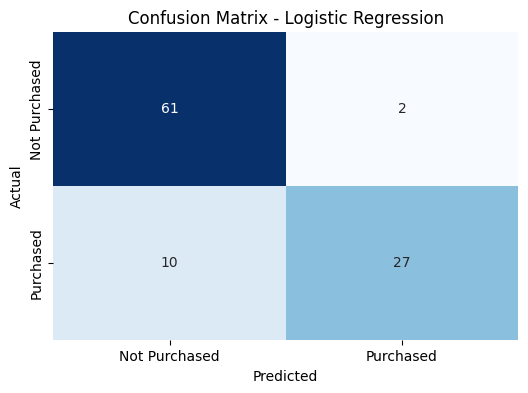


--- Support Vector Machine ---
Accuracy: 0.8700
Confusion Matrix:
[[62  1]
 [12 25]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.98      0.91        63
           1       0.96      0.68      0.79        37

    accuracy                           0.87       100
   macro avg       0.90      0.83      0.85       100
weighted avg       0.88      0.87      0.86       100



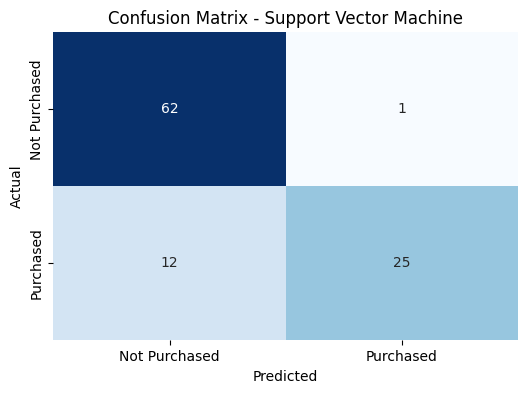


--- Random Forest Classifier ---
Accuracy: 0.8900
Confusion Matrix:
[[57  6]
 [ 5 32]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91        63
           1       0.84      0.86      0.85        37

    accuracy                           0.89       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



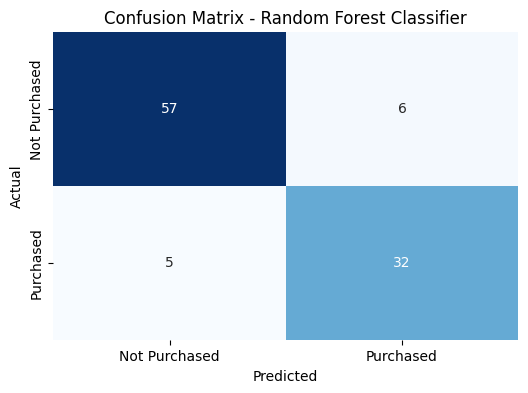


--- Decision Tree Classifier ---
Accuracy: 0.8400
Confusion Matrix:
[[56  7]
 [ 9 28]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88        63
           1       0.80      0.76      0.78        37

    accuracy                           0.84       100
   macro avg       0.83      0.82      0.83       100
weighted avg       0.84      0.84      0.84       100



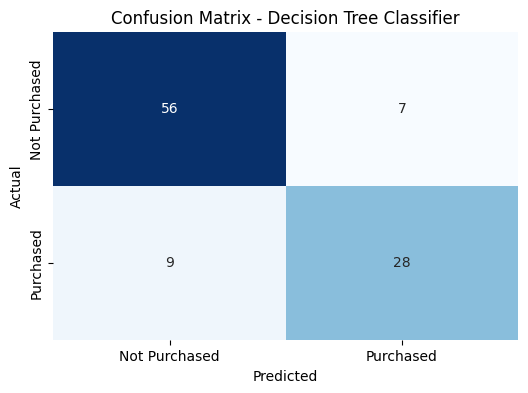

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    print(f"\n--- {model_name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(report)

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Purchased', 'Purchased'],
                yticklabels=['Not Purchased', 'Purchased'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# 1. Logistic Regression
log_reg_model = LogisticRegression(random_state=42)
train_and_evaluate_model(log_reg_model, X_train, y_train, X_test, y_test, "Logistic Regression")

# 2. Support Vector Machine (SVC)
svm_model = SVC(kernel='linear', random_state=42) # Using linear kernel for simplicity
train_and_evaluate_model(svm_model, X_train, y_train, X_test, y_test, "Support Vector Machine")

# 3. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
train_and_evaluate_model(rf_model, X_train, y_train, X_test, y_test, "Random Forest Classifier")

# 4. Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
train_and_evaluate_model(dt_model, X_train, y_train, X_test, y_test, "Decision Tree Classifier")